<a href="https://colab.research.google.com/github/IsuPaul/Indpendent-Research/blob/IR_Codes/IR_Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENHANCED MACHINE LEARNING MODEL FOR 3D PRINTING CONCRETE COMPRESSIVE STRENGTH PREDICTION

## Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xbt
import matplotlib.pyplot as plt
import shap
from sklearn.utils import resample
from sklearn.preprocessing import scale
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import kernels, GaussianProcessRegressor
from sklearn.inspection import PartialDependenceDisplay

## DATA MANAGEMENT AND CLEANING

### Visualization and Description of Uncleaned Data

In [2]:
df = pd.read_csv('Datasets.csv', encoding='latin-1')

In [3]:
#df.head()

In [4]:
#df.describe()

### Determining the type of data in each column

In [5]:
#df.dtypes

### Converting all data to float

In [6]:
df['Carbonated RFA (Kg)']=df['Carbonated RFA (Kg)'].astype(float)
df['PP (Kg)']=df['PP (Kg)'].astype(float)
df['Silica Powder (Kg)']=df['Silica Powder (Kg)'].astype(float)
df['AT (Kg)']=df['AT (Kg)'].astype(float)
#df.dtypes

### Checking for missing data

In [7]:
#df.isnull().sum()

### Fixing Missing Data

In [8]:
imputer_gbt = IterativeImputer(max_iter=10, random_state=42)
imputed_data=imputer_gbt.fit_transform(df)
imputed_data = np.maximum(imputed_data, 0)
imputed_df=pd.DataFrame(imputed_data,columns=df.columns)

### Reconfirm to check for missing data

In [9]:
#imputed_df.isnull().sum()

### Features Distributions

In [10]:
for i in imputed_df.columns:
    plt.figure(figsize=(2.5, 2.5))
    plt.hist(imputed_df[i])
    plt.xlabel(f"{i}",fontsize=7)
    plt.ylabel("Frequency",fontsize=7)
    plt.title(" ")
    plt.tight_layout()
    plt.savefig(f"{i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close('all')

## MODEL DEVELOPEMENTS

#### Assigning Variables

In [11]:
X=imputed_df.drop('Compressive Strength (MPa)',axis=1).copy()
y=imputed_df['Compressive Strength (MPa)'].copy()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

#### Scaling the dataframe and assigning variables for SVM

In [19]:
sdf=(imputed_df-imputed_df.min())/(imputed_df.max()-imputed_df.min())
X_svm=sdf.drop('Compressive Strength (MPa)',axis=1).copy()
y_svm=sdf['Compressive Strength (MPa)'].copy()
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_svm, y_svm, test_size=0.3,random_state=42)

Hyperparameter Tunning of Models

In [72]:
# 1. Hyperparameter Tuning Grids
param_grids = {
    'XGBoost': {'learning_rate': [0.1, 0.2], 'max_depth': [1,3,4,], 'n_estimators': [500, 1000]},
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'DecisionTree': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

# Models to optimize (Linear Regression doesn't typically need grid search for basic form)
models_to_tune = {
    'XGBoost': xbt.XGBRegressor(random_state=42),
    'SVM': svm.SVR(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

optimized_models = {}

# 2. Optimization and Evaluation Loop
for name, model in models_to_tune.items():
    print(f'Optimizing {name}...')
    current_X_train = Xs_train if name == 'SVM' else X_train
    current_y_train = ys_train if name == 'SVM' else y_train
    current_X_test = Xs_test if name == 'SVM' else X_test
    current_y_test = ys_test if name == 'SVM' else y_test

    grid = GridSearchCV(model, param_grids[name], cv=10, scoring='neg_mean_squared_error')
    #grid = GridSearchCV(model, param_grids[name], cv=10, scoring='r2', n_jobs=-1)
    grid.fit(current_X_train, current_y_train)
    best_model = grid.best_estimator_
    optimized_models[name] = best_model

Optimizing XGBoost...
Optimizing SVM...
Optimizing RandomForest...
Optimizing DecisionTree...
Optimizing KNN...


### EXTREME GRADIENT BOOSTING

#### Training the model

In [13]:
clf=xbt.XGBRegressor()
clf.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#### Model Validation

##### Evaluation of Training Data

In [14]:
y_pred = clf.predict(X_train)
mse=mean_squared_error(y_train, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_train, y_pred)
maer_xA=mean_absolute_error(y_train, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 0.6202199883866816
Root Mean Squared Error: 1.5965955626174413
R-Squared Score: 0.9967168480685068


##### Evaluation of Testing Data

In [15]:
y_pred = clf.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)
maer_xA=mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 3.4798958325090488
Root Mean Squared Error: 4.880272101388487
R-Squared Score: 0.9712921297809599


#### Model Optimization (Hyperparameter Tunning)

In [16]:
parameters={ 'learning_rate': [0.2] , 'max_depth':  [4] , 'n_estimators': [1000] }
model= xbt.XGBRegressor()
grid_model=GridSearchCV(model, parameters, cv=10, scoring="neg_mean_squared_error")
grid_model.fit(X_train, y_train)
print("Best set of hyperparameters: ",grid_model.best_params_)
print("Best score: ",grid_model.best_score_)

Best set of hyperparameters:  {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 1000}
Best score:  -71.92635295767641


##### Evaluation of Training Data

In [17]:
best_model= grid_model.best_estimator_
y_predict=best_model.predict(X_train)
mse1=mean_squared_error(y_train, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_train, y_predict)
maer_x=mean_absolute_error(y_train, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 0.48285498715038844
Root Mean Squared Error: 1.5769628829451252
R-Squared Score: 0.9967970947767296


##### Evaluation of Testing Data

In [18]:
best_model= grid_model.best_estimator_
y_predict=best_model.predict(X_test)
mse1=mean_squared_error(y_test, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_test, y_predict)
maer_x=mean_absolute_error(y_test, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 3.3600906478373473
Root Mean Squared Error: 4.7837082709127525
R-Squared Score: 0.9724169508033963


### SUPPORT VECTOR MACHINE MODEL

#### Assigning variables for the model

In [20]:
X_svm=sdf.drop('Compressive Strength (MPa)',axis=1).copy()
y_svm=sdf['Compressive Strength (MPa)'].copy()
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_svm, y_svm, test_size=0.3,random_state=42)

In [22]:
model_svm = svm.SVR()

#### Training the model

In [23]:
model_svm.fit(Xs_train, ys_train)

SVR()

#### Model Validation

##### Evaluation of Training Data

In [24]:
ys_pred = model_svm.predict(Xs_train)
mses=mean_squared_error(ys_train, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(ys_train, ys_pred)
maer_xs=mean_absolute_error(ys_train, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 0.055019823591760136
Root Mean Squared Error: 0.0642131212353541
R-Squared Score: 0.8505576241992818


##### Evaluation of Testing Data

In [25]:
ys_pred = model_svm.predict(Xs_test)
mses=mean_squared_error(ys_test, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(ys_test, ys_pred)
maer_xs=mean_absolute_error(ys_test, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 0.061357776837041855
Root Mean Squared Error: 0.07220429126822395
R-Squared Score: 0.8231667304037942


### RANDOM FOREST

#### Assigning variables for the model

In [26]:
model_rf=RandomForestRegressor(random_state=42)

#### Training the model

In [27]:
model_rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

#### Model Validation

##### Evaluation of Training Data

In [28]:
yr_pred = model_rf.predict(X_train)
mser=mean_squared_error(y_train, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_train, yr_pred)
r2r=r2_score(y_train, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 2.076068773922095
Root Mean Squared Error: 3.3235617534275126
R-Squared Score: 0.9857731533597593


##### Evaluation of Testing Data

In [29]:
yr_pred = model_rf.predict(X_test)
mser=mean_squared_error(y_test, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_test, yr_pred)
r2r=r2_score(y_test, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 3.9814030493244124
Root Mean Squared Error: 5.821562666686459
R-Squared Score: 0.9591500006449265


### DECISION TREE

#### Assigning variables for the model

In [30]:
model_dt=DecisionTreeRegressor()

#### Training the model

In [31]:
model_dt.fit(X_train, y_train)

DecisionTreeRegressor()

#### Model Validation

##### Evaluation of Training Data

In [32]:
yd_pred = model_dt.predict(X_train)
msed=mean_squared_error(y_train, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_train, yd_pred)
r2d=r2_score(y_train, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 0.4761761229314422
Root Mean Squared Error: 1.5769048858166843
R-Squared Score: 0.9967973303636185


##### Evaluation of Testing Data

In [33]:
yd_pred = model_dt.predict(X_test)
msed=mean_squared_error(y_test, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_test, yd_pred)
r2d=r2_score(y_test, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 4.228380165289256
Root Mean Squared Error: 6.496330884893708
R-Squared Score: 0.9491314714968935


### MULTILINEAR REGRESSION

#### Assigning variables for the model

In [34]:
model_ml=LinearRegression()

#### Training the model

In [35]:
model_ml.fit(X_train, y_train)

LinearRegression()

#### Model Validation

##### Evaluation of Training Data

In [36]:
ym_pred = model_ml.predict(X_train)
msem=mean_squared_error(y_train, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_train, ym_pred)
r2m=r2_score(y_train, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 5.755305081158454
Root Mean Squared Error: 8.026372411859414
R-Squared Score: 0.9170264335402404


##### Evaluation of Testing Data

In [37]:
ym_pred = model_ml.predict(X_test)
msem=mean_squared_error(y_test, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_test, yd_pred)
r2m=r2_score(y_test, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 4.228380165289256
Root Mean Squared Error: 9.324827820736402
R-Squared Score: 0.8951919735267084


In [38]:
print(f'Coefficients: {model_ml.coef_}')
print(f'Intercept: {model_ml.intercept_}')

Coefficients: [ 8.54677925e-02 -1.98464151e-01 -2.04656968e-04  1.15204360e-01
  5.28759414e-02  3.62636686e-01 -8.13930750e-02  2.82634000e+00
  1.67490465e+00 -5.08885768e+00 -5.88227367e-01  2.70492234e-02
 -1.36280241e+00  4.76442130e+00  2.10285228e+01 -7.57679576e+00
  1.69828958e+01 -1.31072220e-02  1.89213637e-02  7.17344131e-02
  4.53935621e-01 -6.71390269e-01  6.83590780e-02 -3.26390806e+00
 -6.34179043e-03 -1.18515055e-01 -6.93899122e-02 -8.89092011e-03
 -3.40934153e-01 -1.32016734e+00 -3.09978680e+00  4.67813746e+01
 -8.80936931e-03 -1.24469547e+01 -1.25812981e-02  1.42322228e-02
 -2.32807586e+01]
Intercept: 29.90325858298452


### KNN NEIGHBORS

#### Assigning variables for the model

In [39]:
model_kn=KNeighborsRegressor(2)

#### Training the model

In [40]:
model_kn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=2)

#### Model Validation

##### Evaluation of Training Data

In [41]:
yk_pred = model_kn.predict(X_train)
msek=mean_squared_error(y_train, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_train, yk_pred)
r2k=r2_score(y_train, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 4.084716312056738
Root Mean Squared Error: 6.638903053616549
R-Squared Score: 0.9432332803739331


##### Evaluation of Testing Data

In [42]:
yk_pred = model_kn.predict(X_test)
msek=mean_squared_error(y_test, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_test, yk_pred)
r2k=r2_score(y_test, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 7.5978471074380165
Root Mean Squared Error: 13.098847002678777
R-Squared Score: 0.7931864262041165


## VISUALIZATION OF MODEL PERFORMANCE

### SHAP ANALYSIS

In [43]:
# SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

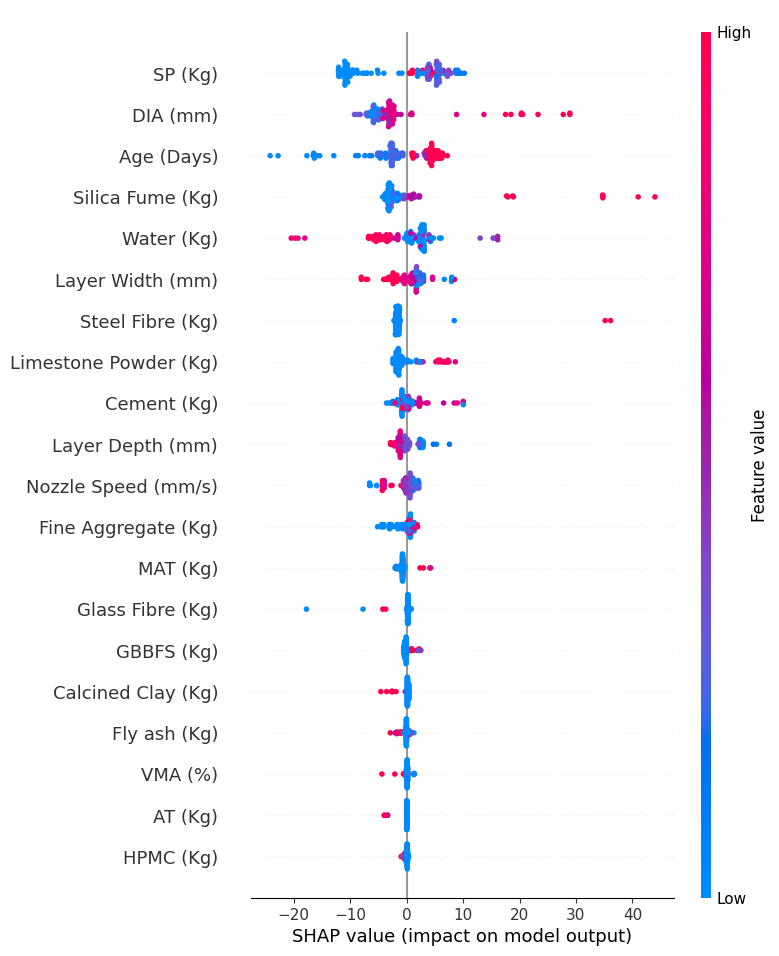

In [44]:
# Plot SHAP summary with minimized height
plt.figure(figsize=(4, 4))  # Adjusted height to minimize the plot size
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)  # Set show=False to prevent auto-display
plt.gca().set_title(" ")  # Optional: Set a title for clarity
plt.savefig("SHAP1.jpg")
#plt.show()

In [45]:
exp=shap.Explainer(best_model)
shap_values = exp(X_test)
plt.figure(figsize=(3.2, 3.4))
shap.plots.waterfall(shap_values[60], show=False)
plt.tight_layout()
plt.savefig("WATERFALL.jpg")
plt.close()

In [46]:
plt.figure(figsize=(4, 2))
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("BAR_IMPORTANCE.jpg")
plt.close()

In [47]:
#Partial Dependence Plot (PDP)
for i in X_test.columns:
    fig, ax = plt.subplots(figsize=(3.5, 3.5)) # Create figure and axes objects
    PartialDependenceDisplay.from_estimator(best_model, X_test, [i], ax=ax) # Pass axes to display
    ax.set_xlabel(f"{i}", fontsize=8) # Use ax.set_xlabel instead of plt.xlabel
    ax.set_ylabel("Partial Dependence", fontsize=8) # Use ax.set_ylabel instead of plt.ylabel
    ax.set_title(f" ") # Use ax.set_title instead of plt.title
    plt.tight_layout()
    plt.savefig(f" PDP of {i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close(fig) # Close the figure objec

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-p

### Scatter Plot of XGBOOST

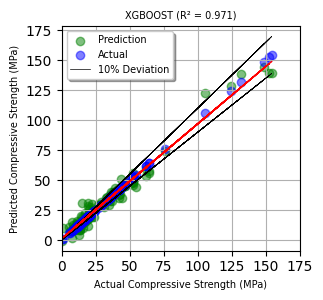

In [48]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=1)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"XGBOOST (R² = {r2:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_XGBOOST.jpg")
plt.show()

### Scatter Plot of XGBOOST+

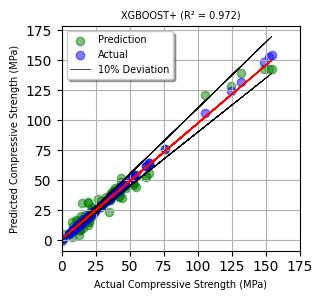

In [49]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_predict, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, y_predict, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=1)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"XGBOOST+ (R² = {r21:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_XGBOOST+.jpg")
plt.show()

### Scatter Plot of SVM Model

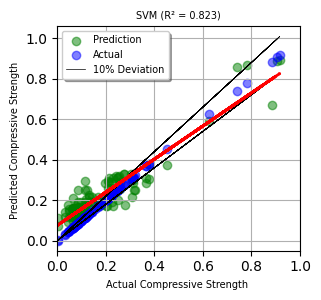

In [50]:
# Calculate the 10% deviation
deviation = 0.10 * ys_test
lower_bound = ys_test - deviation
upper_bound = ys_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(ys_test, ys_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(ys_test, ys_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(ys_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(ys_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(ys_test, ys_pred, 1)
plt.plot(ys_test, m * ys_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength ",fontsize=7)
plt.ylabel("Predicted Compressive Strength ",fontsize=7)
plt.title(f"SVM (R² = {r2s:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 1
interval = 0.2
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_SVM.jpg")
plt.show()

### Scatter Plot of RF Model

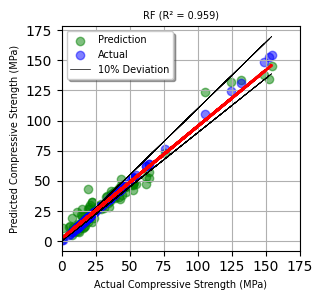

In [51]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, yr_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yr_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"RF (R² = {r2r:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_RF.jpg")
plt.show()

### Scatter Plot of DT Model

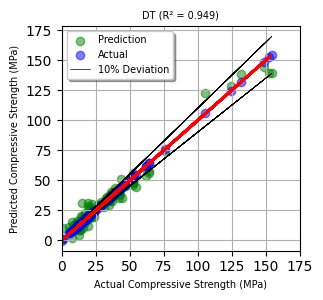

In [52]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yd_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"DT (R² = {r2d:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_DT.jpg")
plt.show()

### Scatter Plot of MLR Model

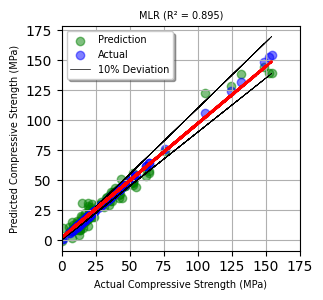

In [53]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, ym_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)",fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)",fontsize=7)
plt.title(f"MLR (R² = {r2m:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_MLR.jpg")
plt.show()

### Scatter Plot of KNN Model

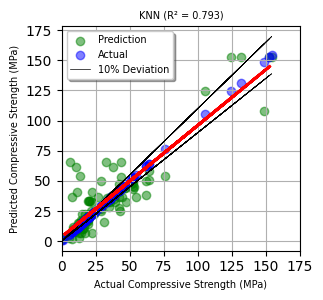

In [54]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, yk_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yk_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"KNN (R² = {r2k:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_KNN.jpg")
plt.show()

### Material Model

In [55]:
columns_to_remove = ['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']
X_new = imputed_df.drop(columns_to_remove, axis=1).drop('Compressive Strength (MPa)', axis=1).copy()
y_new = imputed_df['Compressive Strength (MPa)'].copy()

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

#parameters_new={ 'learning_rate': [0.2] , 'max_depth':  [4] , 'n_estimators': [1000] }
#model_new= xbt.XGBRegressor()
#grid_model_new=GridSearchCV(model_new, parameters_new, cv=10, scoring="neg_mean_squared_error")
#grid_model_new.fit(X_train_new, y_train_new)
grid_model_new=xbt.XGBRegressor()
grid_model_new.fit(X_train_new, y_train_new)

# Use the grid_model to forecast the model
y_predict_new = grid_model_new.predict(X_test_new)

# Evaluate the model
mse_new = mean_squared_error(y_test_new, y_predict_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_predict_new)
maer_new = mean_absolute_error(y_test_new, y_predict_new)

print("Mean Absolute Error:", maer_new)
print("Root Mean Squared Error:", rmse_new)
print("R-Squared Score:", r2_new)

Mean Absolute Error: 4.610374470486129
Root Mean Squared Error: 6.578165333116978
R-Squared Score: 0.9478418150822137


#### Scatter Plot of Material Model

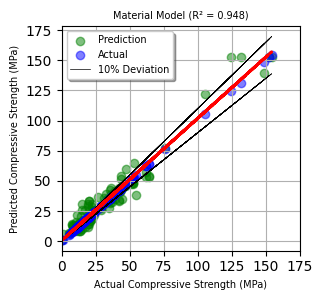

In [56]:
# Calculate the 10% deviation
deviation = 0.10 * y_test_new
lower_bound = y_test_new - deviation
upper_bound = y_test_new + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test_new, y_predict_new, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test_new, y_test_new, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test_new, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test_new, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test_new, y_predict_new, 1)
plt.plot(y_test_new, m * y_test_new + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"Material Model (R² = {r2_new:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_Material.jpg")
plt.show()

### Printing Model

In [57]:
X_new = imputed_df[['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']].copy()
y_new = imputed_df['Compressive Strength (MPa)'].copy()

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.3, random_state=42
)
grid_model_new=xbt.XGBRegressor()
grid_model_new.fit(X_train_new, y_train_new)
# Use the grid_model to forecast the model
y_predict_new = grid_model_new.predict(X_test_new)

# Evaluate the model
mse_new = mean_squared_error(y_test_new, y_predict_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_predict_new)
maer_new = mean_absolute_error(y_test_new, y_predict_new)

print("Mean Absolute Error:", maer_new)
print("Root Mean Squared Error:", rmse_new)
print("R-Squared Score:", r2_new)

Mean Absolute Error: 7.080698582121163
Root Mean Squared Error: 11.982427295053917
R-Squared Score: 0.8269376863542055


#### Scatter Plot of Printing Model

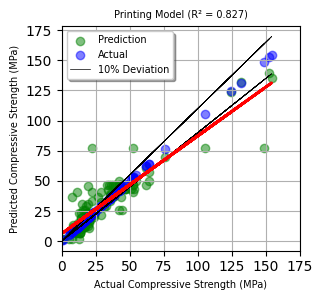

In [58]:
# Calculate the 10% deviation
deviation = 0.10 * y_test_new
lower_bound = y_test_new - deviation
upper_bound = y_test_new + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test_new, y_predict_new, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test_new, y_test_new, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test_new, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test_new, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test_new, y_predict_new, 1)
plt.plot(y_test_new, m * y_test_new + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"Printing Model (R² = {r2_new:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_Printing.jpg")
plt.show()

### Exporting Results to excel

In [59]:
#summary = df.describe(include='all')
#summary1=imputed_df.describe(include = 'all')

In [60]:
# Export the summary data frame to an Excel
#summary1.to_excel('summary_data.xlsx', sheet_name='Summary', index=True, header=True)
#summary.to_excel('summary1_dataframe.xlsx', sheet_name='Summary1 Data')
# Export the cleaned data frame to an Excel
#imputed_df.to_excel('imputed_df_dataframe.xlsx', sheet_name='Cleaned Data')

## LEARNING CURVES

In [61]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 10)):
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(6, 4))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples", fontsize=8)
    axes.set_ylabel("MSE", fontsize=8)

    # Using neg_mean_squared_error for scoring
    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes,
                       return_times=True, scoring='neg_mean_squared_error')

    # Negate scores to show positive MSE
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training error (MSE)")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation error (MSE)")
    axes.legend(loc="best", fontsize=7)

    return plt

# Learning Curve for XGBoost (MSE)
fig, ax = plt.subplots(figsize=(4, 3))
plot_learning_curve(best_model, "LC MSE (XGBoost)", X_train, y_train, axes=ax, cv=5, n_jobs=-1)
plt.tight_layout()
plt.savefig("LC_MSE_XGBoost.jpg")
plt.close(fig)

# Learning Curve for SVM (MSE)
fig, ax = plt.subplots(figsize=(4, 3))
plot_learning_curve(model_svm, "LC MSE (SVM)", Xs_train, ys_train, axes=ax, cv=5, n_jobs=-1)
plt.tight_layout()
plt.savefig("LC_MSE_SVM.jpg")
plt.close(fig)

# Learning Curve for Random Forest (MSE)
fig, ax = plt.subplots(figsize=(4, 3))
plot_learning_curve(model_rf, "LC MSE (Random Forest)", X_train, y_train, axes=ax, cv=5, n_jobs=-1)
plt.tight_layout()
plt.savefig("LC_MSE_RandomForest.jpg")
plt.close(fig)

# Learning Curve for Decision Tree (MSE)
fig, ax = plt.subplots(figsize=(4, 3))
plot_learning_curve(model_dt, "LC MSE (Decision Tree)", X_train, y_train, axes=ax, cv=5, n_jobs=-1)
plt.tight_layout()
plt.savefig("LC_MSE_DecisionTree.jpg")
plt.close(fig)

# Learning Curve for Multilinear Regression (MSE)
fig, ax = plt.subplots(figsize=(4, 3))
plot_learning_curve(model_ml, "LC MSE (Linear Regression)", X_train, y_train, axes=ax, cv=5, n_jobs=-1)
plt.tight_layout()
plt.savefig("LC_MSE_LinearRegression.jpg")
plt.close(fig)

# Learning Curve for KNN (MSE)
fig, ax = plt.subplots(figsize=(4, 3))
plot_learning_curve(model_kn, "LC MSE (KNN)", X_train, y_train, axes=ax, cv=5, n_jobs=-1)
plt.tight_layout()
plt.savefig("LC_MSE_KNN.jpg")
plt.close(fig)

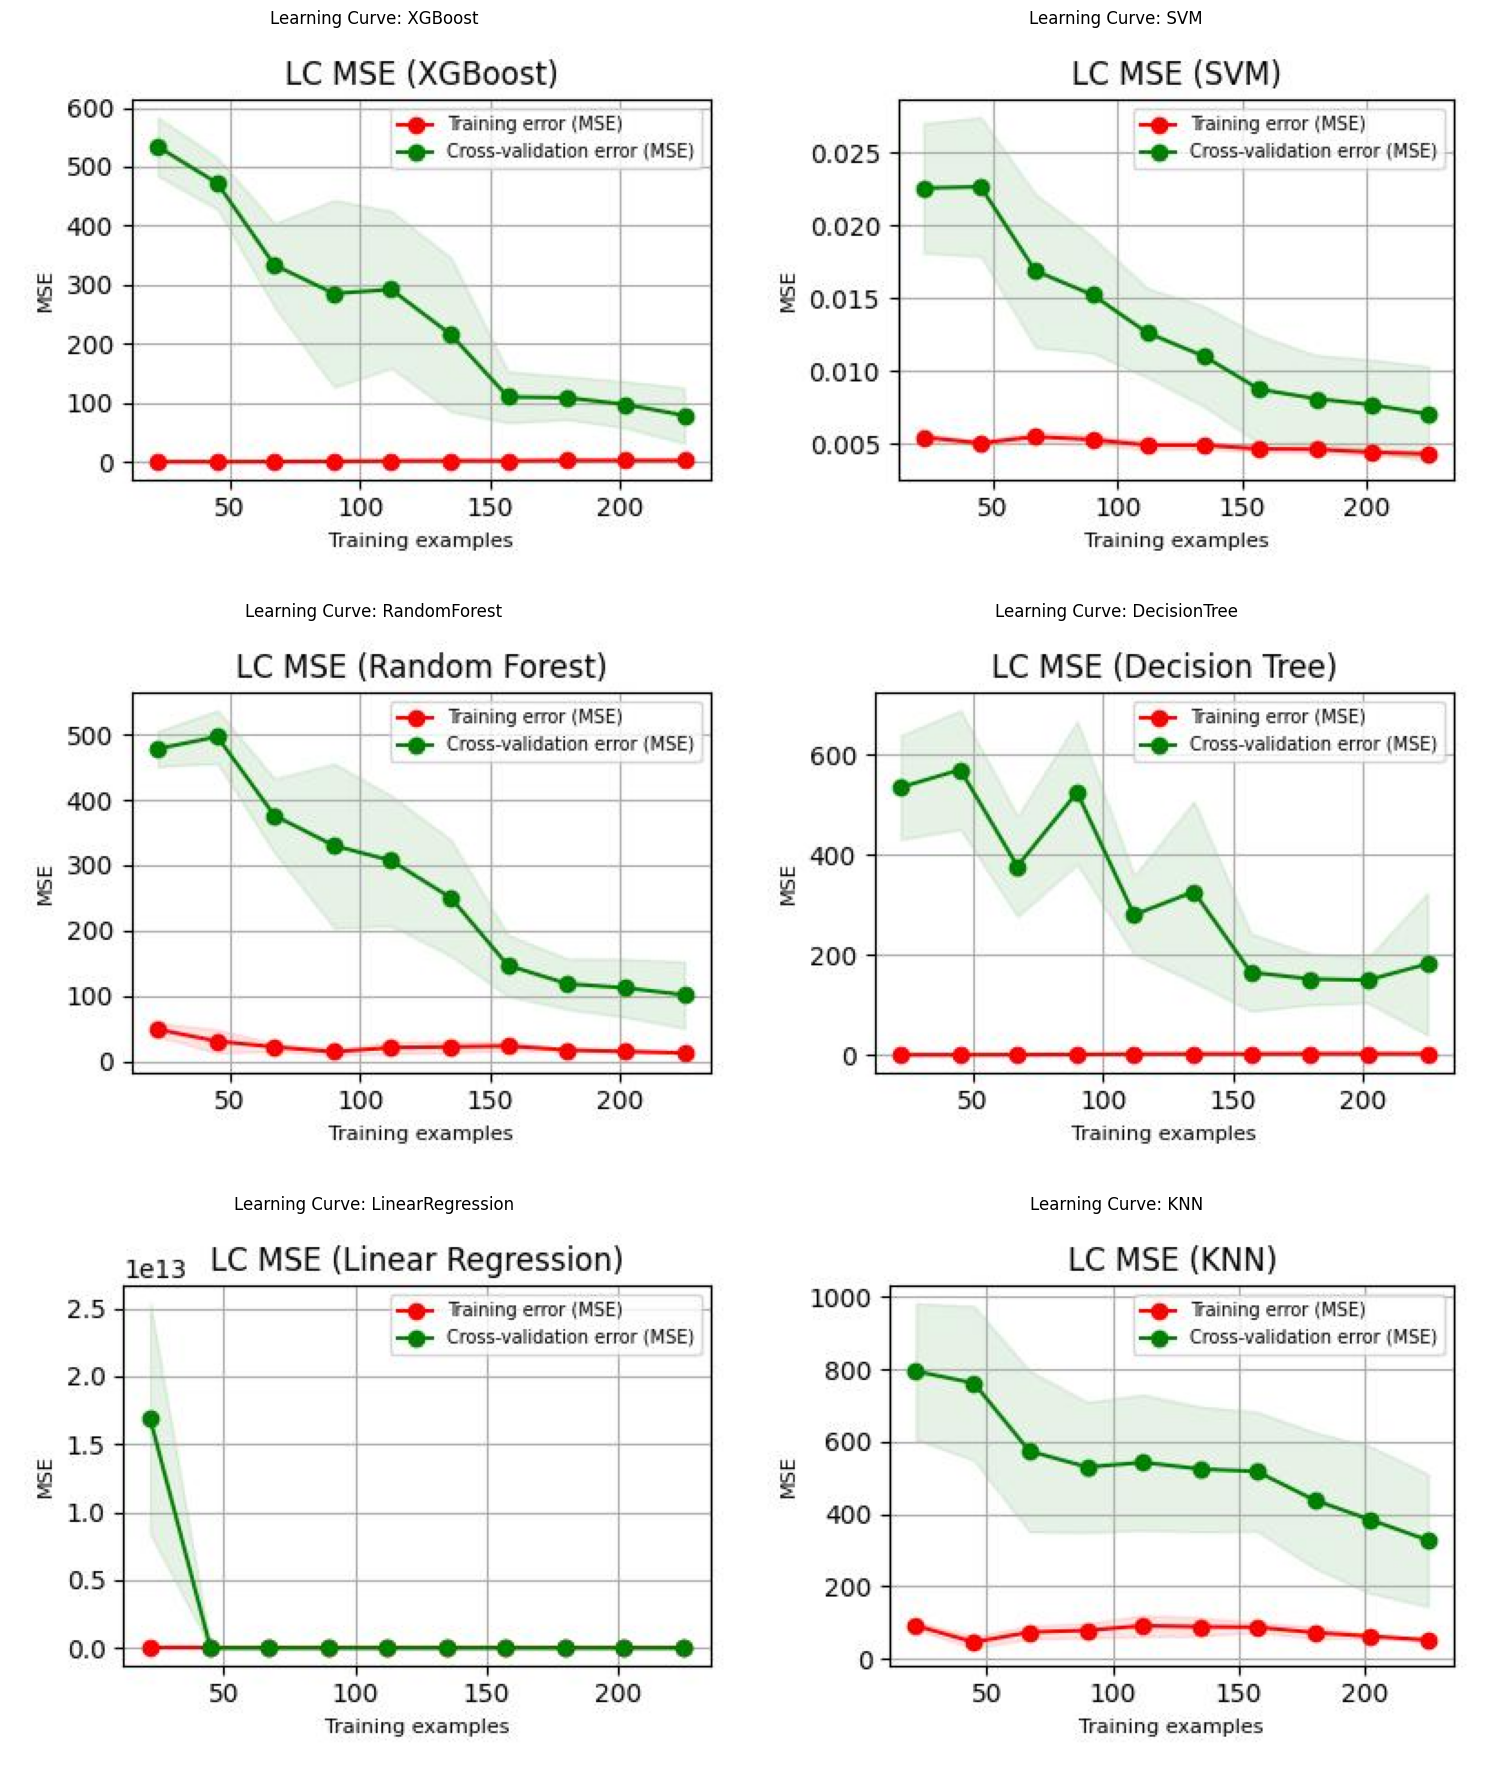

In [62]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

models = ['XGBoost', 'SVM', 'RandomForest', 'DecisionTree', 'LinearRegression', 'KNN']
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, model in enumerate(models):
    img_path = f'LC_MSE_{model}.jpg'
    try:
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'Learning Curve: {model}')
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, f'{img_path} not found', ha='center')

plt.tight_layout()
plt.show()

In [63]:
import pandas as pd

def get_lc_data(estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='neg_mean_squared_error'
    )[:3]
    df_lc = pd.DataFrame({
        'Training_Size': train_sizes,
        'Train_MSE_Mean': -np.mean(train_scores, axis=1),
        'Train_MSE_Std': np.std(train_scores, axis=1),
        'CV_MSE_Mean': -np.mean(test_scores, axis=1),
        'CV_MSE_Std': np.std(test_scores, axis=1)
    })
    return df_lc

# Prepare to save to Excel
with pd.ExcelWriter('learning_curves_data.xlsx') as writer:
    get_lc_data(best_model, X_train, y_train).to_excel(writer, sheet_name='XGBoost', index=False)
    get_lc_data(model_svm, Xs_train, ys_train).to_excel(writer, sheet_name='SVM', index=False)
    get_lc_data(model_rf, X_train, y_train).to_excel(writer, sheet_name='RandomForest', index=False)
    get_lc_data(model_dt, X_train, y_train).to_excel(writer, sheet_name='DecisionTree', index=False)
    get_lc_data(model_ml, X_train, y_train).to_excel(writer, sheet_name='LinearRegression', index=False)
    get_lc_data(model_kn, X_train, y_train).to_excel(writer, sheet_name='KNN', index=False)

print("Learning curve data has been saved to 'learning_curves_data.xlsx'")

Learning curve data has been saved to 'learning_curves_data.xlsx'


Optimizing XGBoost...
Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000}
XGBoost Train -> MAE: 0.4786, RMSE: 1.5769, R2: 0.9968
XGBoost Test -> MAE: 3.4375, RMSE: 4.9574, R2: 0.9704
Optimizing SVM...
Best Params for SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVM Train -> MAE: 0.0516, RMSE: 0.0621, R2: 0.8604
SVM Test -> MAE: 0.0541, RMSE: 0.0669, R2: 0.8484
Optimizing RandomForest...
Best Params for RandomForest: {'max_depth': None, 'n_estimators': 200}
RandomForest Train -> MAE: 2.0812, RMSE: 3.2943, R2: 0.9860
RandomForest Test -> MAE: 3.8848, RMSE: 5.7332, R2: 0.9604
Optimizing DecisionTree...
Best Params for DecisionTree: {'max_depth': 10, 'min_samples_split': 2}
DecisionTree Train -> MAE: 2.4968, RMSE: 4.5033, R2: 0.9739
DecisionTree Test -> MAE: 5.2753, RMSE: 8.0143, R2: 0.9226
Optimizing KNN...
Best Params for KNN: {'n_neighbors': 7, 'weights': 'distance'}
KNN Train -> MAE: 0.4762, RMSE: 1.5769, R2: 0.9968
KNN Test -> MAE: 7.3332, RMSE: 1

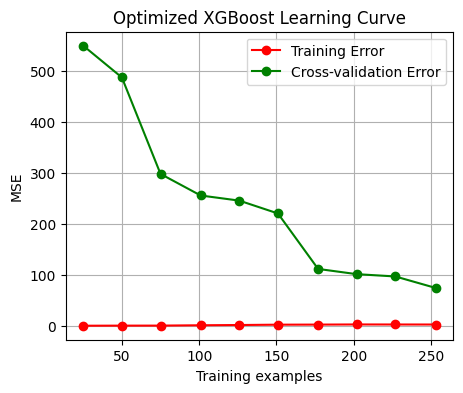

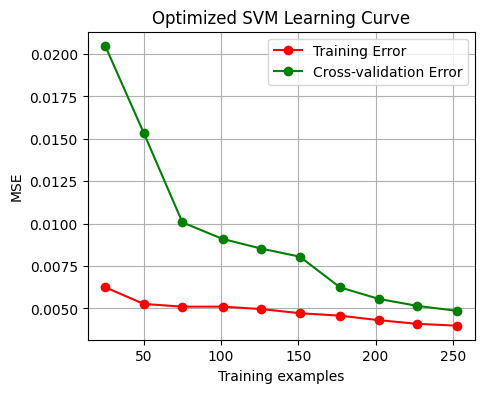

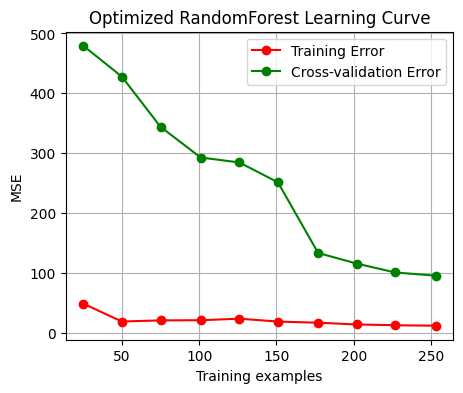

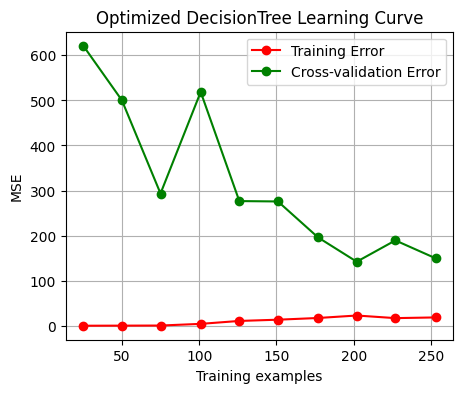

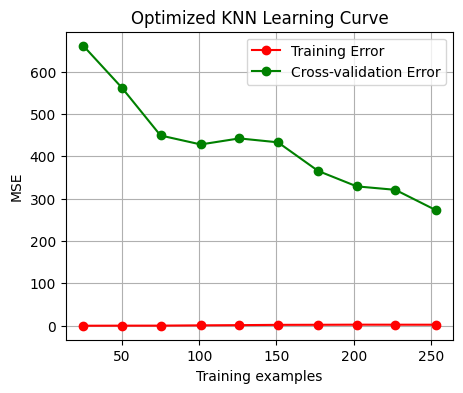

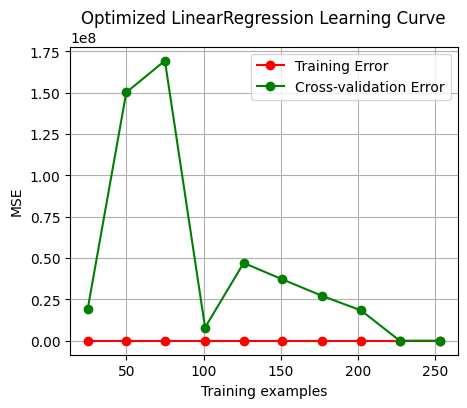

In [71]:
from sklearn.model_selection import GridSearchCV, learning_curve

# 1. Hyperparameter Tuning Grids
param_grids = {
    'XGBoost': {'learning_rate': [0.1, 0.2], 'max_depth': [4, 6], 'n_estimators': [500, 1000]},
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'DecisionTree': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

# Models to optimize (Linear Regression doesn't typically need grid search for basic form)
models_to_tune = {
    'XGBoost': xbt.XGBRegressor(random_state=42),
    'SVM': svm.SVR(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

optimized_models = {}

# 2. Optimization and Evaluation Loop
for name, model in models_to_tune.items():
    print(f'Optimizing {name}...')
    current_X_train = Xs_train if name == 'SVM' else X_train
    current_y_train = ys_train if name == 'SVM' else y_train
    current_X_test = Xs_test if name == 'SVM' else X_test
    current_y_test = ys_test if name == 'SVM' else y_test

    grid = GridSearchCV(model, param_grids[name], cv=10, scoring='neg_mean_squared_error')
    #grid = GridSearchCV(model, param_grids[name], cv=10, scoring='r2', n_jobs=-1)
    grid.fit(current_X_train, current_y_train)
    best_model = grid.best_estimator_
    optimized_models[name] = best_model

    print(f'Best Params for {name}: {grid.best_params_}')

    for data_name, cur_X, cur_y in [('Train', current_X_train, current_y_train), ('Test', current_X_test, current_y_test)]:
        preds = best_model.predict(cur_X)
        mse = mean_squared_error(cur_y, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(cur_y, preds)
        r2 = r2_score(cur_y, preds)
        print(f'{name} {data_name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}')

# Adding Linear Regression for the Learning Curves step
optimized_models['LinearRegression'] = LinearRegression().fit(X_train, y_train)

# 3. Learning Curves for Optimized Models
def plot_final_lc(estimator, title, X, y, filename):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=10, n_jobs=-1, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
    )
    plt.figure(figsize=(5, 4))
    plt.plot(train_sizes, -np.mean(train_scores, axis=1), 'o-', color='r', label='Training Error')
    plt.plot(train_sizes, -np.mean(test_scores, axis=1), 'o-', color='g', label='Cross-validation Error')
    plt.title(f'Optimized {title} Learning Curve')
    plt.xlabel('Training examples')
    plt.ylabel('MSE')
    plt.legend(loc='best')
    plt.grid(True)
    plt.savefig(filename)
    plt.show()

for name, model in optimized_models.items():
    cur_X = Xs_train if name == 'SVM' else X_train
    cur_y = ys_train if name == 'SVM' else y_train
    plot_final_lc(model, name, cur_X, cur_y, f'Opt_LC_{name}.jpg')

In [65]:
import pandas as pd

def export_opt_lc_data(estimator, name, X, y, cv=10):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
    )
    df = pd.DataFrame({
        'Training_Size': train_sizes,
        'Train_MSE_Mean': -np.mean(train_scores, axis=1),
        'Train_MSE_Std': np.std(train_scores, axis=1),
        'CV_MSE_Mean': -np.mean(test_scores, axis=1),
        'CV_MSE_Std': np.std(test_scores, axis=1)
    })
    return df

with pd.ExcelWriter('optimized_learning_curves_data.xlsx') as writer:
    for name, model in optimized_models.items():
        cur_X = Xs_train if name == 'SVM' else X_train
        cur_y = ys_train if name == 'SVM' else y_train
        export_opt_lc_data(model, name, cur_X, cur_y).to_excel(writer, sheet_name=name, index=False)

print("Optimized learning curve data saved to 'optimized_learning_curves_data.xlsx'")

Optimized learning curve data saved to 'optimized_learning_curves_data.xlsx'


In [66]:
import pandas as pd

loss_data_frames = {}

for name, model in optimized_models.items():
    if 'XGBoost' in name:
        # Refit to get history
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
        results = model.evals_result()
        df = pd.DataFrame({
            'Iteration': range(len(results['validation_0']['rmse'])),
            'Train_MSE': [x**2 for x in results['validation_0']['rmse']],
            'Val_MSE': [x**2 for x in results['validation_1']['rmse']]
        })
    else:
        train_err, test_err = [], []
        sizes = np.linspace(0.1, 1.0, 10)
        for size in sizes:
            idx = int(size * len(X_train))
            cur_X_train = Xs_train[:idx] if name == 'SVM' else X_train[:idx]
            cur_y_train = ys_train[:idx] if name == 'SVM' else y_train[:idx]
            cur_X_test = Xs_test if name == 'SVM' else X_test
            cur_y_test = ys_test if name == 'SVM' else y_test

            model.fit(cur_X_train, cur_y_train)
            train_err.append(mean_squared_error(cur_y_train, model.predict(cur_X_train)))
            test_err.append(mean_squared_error(cur_y_test, model.predict(cur_X_test)))

        df = pd.DataFrame({
            'Training_Data_Percentage': sizes * 100,
            'Train_MSE': train_err,
            'Val_MSE': test_err
        })
    loss_data_frames[name] = df

with pd.ExcelWriter('optimized_models_loss_data.xlsx') as writer:
    for name, df in loss_data_frames.items():
        df.to_excel(writer, sheet_name=name[:31], index=False)

print("Loss data has been saved to 'optimized_models_loss_data.xlsx'")

Loss data has been saved to 'optimized_models_loss_data.xlsx'


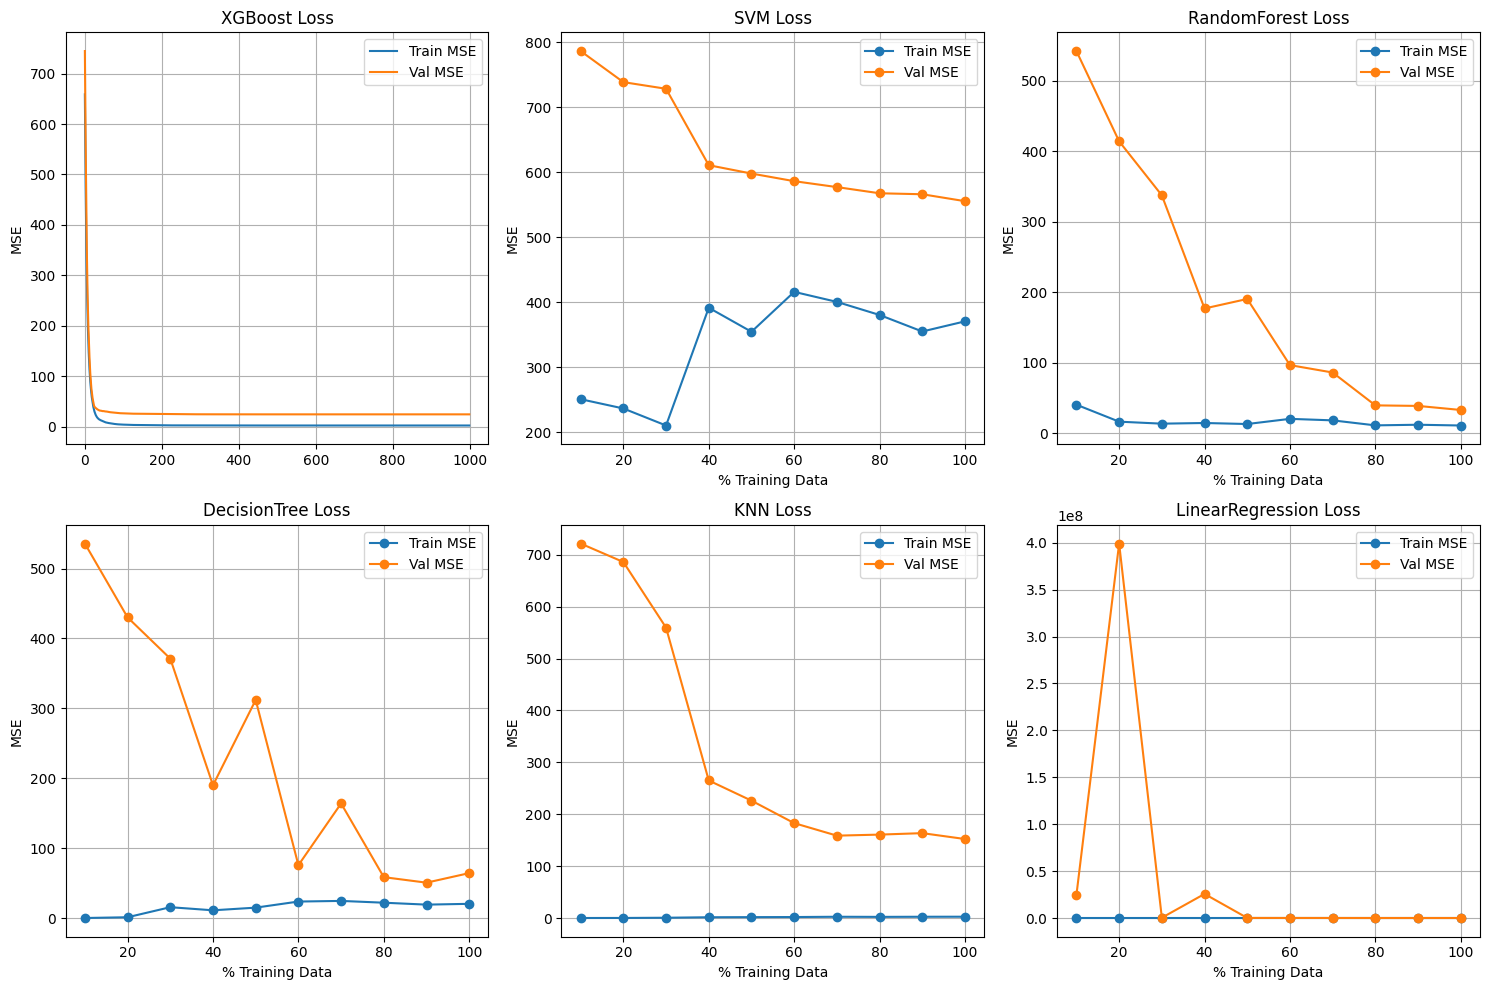

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def plot_loss_comparison(models_dict, X_train, y_train, X_test, y_test):
    plt.figure(figsize=(15, 10))

    for i, (name, model) in enumerate(models_dict.items()):
        plt.subplot(2, 3, i+1)

        # For XGBoost, we can use the internal results
        if 'XGBoost' in name:
            model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
            results = model.evals_result()
            epochs = len(results['validation_0']['rmse'])
            plt.plot(range(epochs), [x**2 for x in results['validation_0']['rmse']], label='Train MSE')
            plt.plot(range(epochs), [x**2 for x in results['validation_1']['rmse']], label='Val MSE')

        # For other models, we plot errors relative to training subsets as a proxy for loss progression
        else:
            train_err, test_err = [], []
            sizes = np.linspace(0.1, 1.0, 10)
            for size in sizes:
                idx = int(size * len(X_train))
                model.fit(X_train[:idx], y_train[:idx])
                train_err.append(mean_squared_error(y_train[:idx], model.predict(X_train[:idx])))
                test_err.append(mean_squared_error(y_test, model.predict(X_test)))
            plt.plot(sizes * 100, train_err, 'o-', label='Train MSE')
            plt.plot(sizes * 100, test_err, 'o-', label='Val MSE')
            plt.xlabel('% Training Data')

        plt.title(f'{name} Loss')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Filter models for comparison (SVM needs scaled data)
plot_loss_comparison(optimized_models, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "algorithm", "leaf_size", "metric", "n_neighbors", "p", "weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


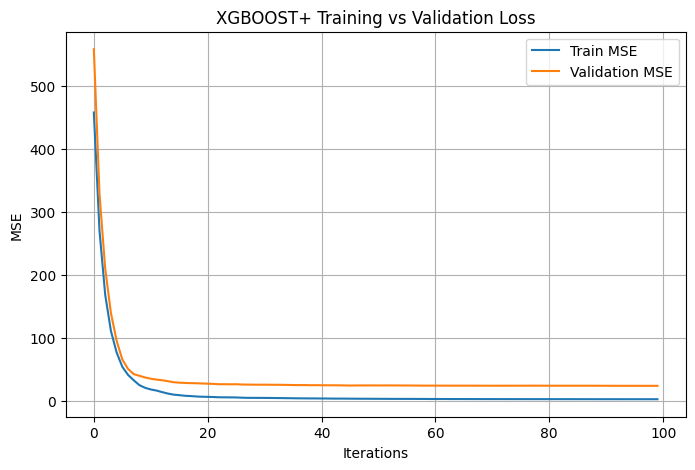

In [68]:
import matplotlib.pyplot as plt

# Get parameters from the best_model identified in previous steps
params = best_model.get_params()
params['eval_metric'] = 'rmse'  # XGBoost uses RMSE internally for regression

# Initialize model with best parameters
model_plus = xbt.XGBRegressor(**params)

# Fit with eval_set to track progress
eval_set = [(X_train, y_train), (X_test, y_test)]
model_plus.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# Retrieve performance metrics
results = model_plus.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Plot MSE (Converting RMSE to MSE by squaring)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_axis, [x**2 for x in results['validation_0']['rmse']], label='Train MSE')
ax.plot(x_axis, [x**2 for x in results['validation_1']['rmse']], label='Validation MSE')
ax.legend()
plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.title('XGBOOST+ Training vs Validation Loss')
plt.grid(True)
plt.show()

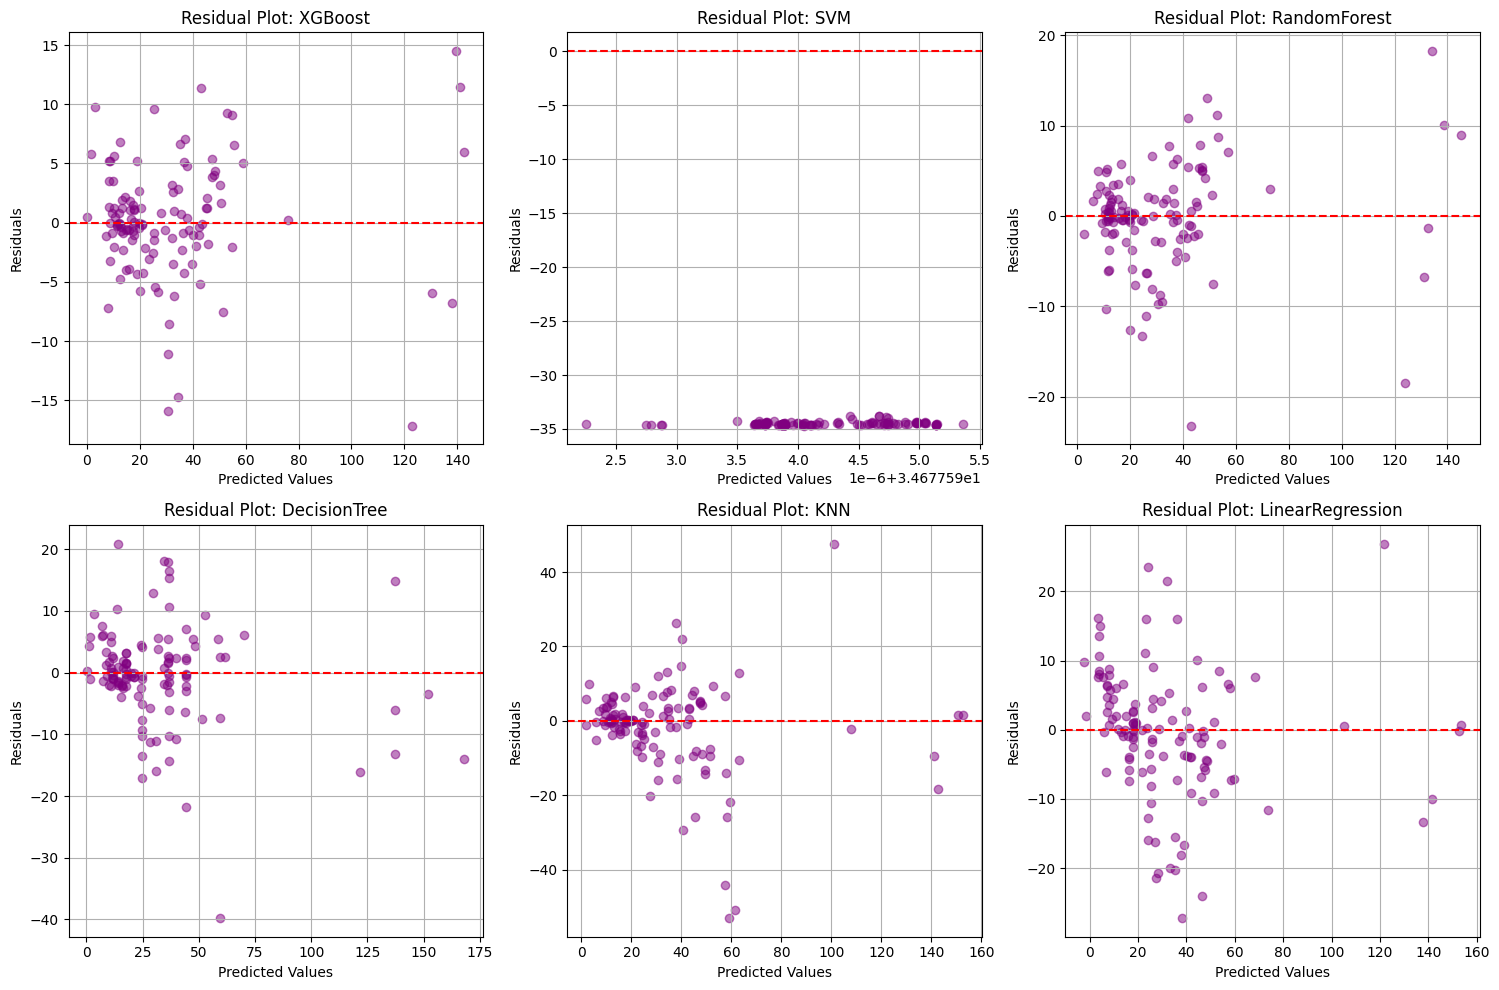

Residual data has been saved to 'models_residuals_data.xlsx'


In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare to store data for Excel
residual_data_frames = {}

# Create the residual plots
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(optimized_models.items()):
    # Select appropriate test data
    current_X_test = Xs_test if name == 'SVM' else X_test
    current_y_test = ys_test if name == 'SVM' else y_test

    # Generate predictions
    y_pred_test = model.predict(current_X_test)
    residuals = current_y_test - y_pred_test

    # Store data for Export
    residual_data_frames[name] = pd.DataFrame({
        'Actual': current_y_test,
        'Predicted': y_pred_test,
        'Residuals': residuals
    })

    # Plotting
    plt.subplot(2, 3, i+1)
    plt.scatter(y_pred_test, residuals, alpha=0.5, color='purple')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot: {name}')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.grid(True)

plt.tight_layout()
plt.savefig("Models_Residual_Plots.jpg")
plt.show()

# Export to Excel
with pd.ExcelWriter('models_residuals_data.xlsx') as writer:
    for name, df in residual_data_frames.items():
        df.to_excel(writer, sheet_name=name[:31], index=False)

print("Residual data has been saved to 'models_residuals_data.xlsx'")